In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Configuración estética
sns.set_theme(style='whitegrid')

# Cargar el dataset de Brasil
df_brasil = pd.read_excel("Dados brutos.xlsx")

# 1. Ver las primeras 5 filas
print("--- Primeras filas del dataset de Energía ---")
display(df_brasil.head())

# 2. Ver la estructura, nombres de columnas y valores nulos
print("--- Informacion del Dataset ---")
df_brasil.info()



--- Primeras filas del dataset de Energía ---


,Data,TipoConsumidor,Sistema,UF,Setor Econômico - N1,Setor Econômico - N2,Setor Econômico - N3,Tipo Tensão - N1,Tipo Tensão - N2,Tipo Tensão - N3,Faixa de Consumo N1,Faixa de Consumo N2,Consumidores,Consumo
0,20140101,Cativo,Sudeste / Centro-Oeste,RO,Residencial,Convencional (Excepto Baixa Renda),TOTAL,A - Alta Tensão,TOTAL,TOTAL,Alta Tensão,Alta Tensão,1.0,8.0
1,20140201,Cativo,Sudeste / Centro-Oeste,RO,Residencial,Convencional (Excepto Baixa Renda),TOTAL,A - Alta Tensão,TOTAL,TOTAL,Alta Tensão,Alta Tensão,1.0,8.0
2,20140301,Cativo,Sudeste / Centro-Oeste,RO,Residencial,Convencional (Excepto Baixa Renda),TOTAL,A - Alta Tensão,TOTAL,TOTAL,Alta Tensão,Alta Tensão,1.0,9.0
3,20140401,Cativo,Sudeste / Centro-Oeste,RO,Residencial,Convencional (Excepto Baixa Renda),TOTAL,A - Alta Tensão,TOTAL,TOTAL,Alta Tensão,Alta Tensão,1.0,10.0
4,20140501,Cativo,Sudeste / Centro-Oeste,RO,Residencial,Convencional (Excepto Baixa Renda),TOTAL,A - Alta Tensão,TOTAL,TOTAL,Alta Tensão,Alta Tensão,1.0,9.0


--- Informacion del Dataset ---
<class 'pandas.DataFrame'>
RangeIndex: 285499 entries, 0 to 285498
Data columns (total 14 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   Data                  285499 non-null  int64  
 1   TipoConsumidor        285499 non-null  str    
 2   Sistema               285499 non-null  str    
 3   UF                    285499 non-null  str    
 4   Setor Econômico - N1  285499 non-null  str    
 5   Setor Econômico - N2  285499 non-null  str    
 6   Setor Econômico - N3  285499 non-null  str    
 7   Tipo Tensão - N1      285499 non-null  str    
 8   Tipo Tensão - N2      285499 non-null  str    
 9   Tipo Tensão - N3      285499 non-null  str    
 10  Faixa de Consumo N1   285499 non-null  str    
 11  Faixa de Consumo N2   285499 non-null  str    
 12  Consumidores          281511 non-null  float64
 13  Consumo               275799 non-null  float64
dtypes: float64(2), int64(1), str(11

In [2]:
# 1. Limpieza de nulos
# Eliminamos las filas donde NO hay datos de Consumo 
df_brasil.dropna(subset=['Consumo'], inplace=True)

# 2. Conversión de fechas
# Convertir el int64 a string temporalmente, y luego le pedimos a pandas que lo convierta a formato Fecha
df_brasil['Data'] = pd.to_datetime(df_brasil['Data'].astype(str), format='%Y%m%d', errors='coerce')

# 3. Establecer la fecha como indice temporal y ordenar
df_brasil.set_index('Data', inplace=True)
df_brasil.sort_index(inplace=True)

# 4. Verificación de la base de operaciones
print("--- Datos listos para Series Temporales ---")
display(df_brasil.head())

--- Datos listos para Series Temporales ---


,TipoConsumidor,Sistema,UF,Setor Econômico - N1,Setor Econômico - N2,Setor Econômico - N3,Tipo Tensão - N1,Tipo Tensão - N2,Tipo Tensão - N3,Faixa de Consumo N1,Faixa de Consumo N2,Consumidores,Consumo
Data,,,,,,,,,,,,,
2014-01-01,Cativo,Sudeste / Centro-Oeste,RO,Residencial,Convencional (Excepto Baixa Renda),TOTAL,A - Alta Tensão,TOTAL,TOTAL,Alta Tensão,Alta Tensão,1.0,8.0
2014-01-01,Cativo,Norte Interligado,TO,Residencial,Convencional (Excepto Baixa Renda),TOTAL,B - Baixa Tensão,TOTAL,TOTAL,Convencional,401-500 kWh,6843.0,3041.0
2014-01-01,Cativo,Sudeste / Centro-Oeste,MS,Comercial,Comercial N2,TOTAL,A - Alta Tensão,"A-4 - 2,3 a 25 kV",TOTAL,Não Aplicável,Não Aplicável,435.0,13864.0
2014-01-01,Cativo,Norte Interligado,TO,Residencial,Convencional (Excepto Baixa Renda),TOTAL,B - Baixa Tensão,TOTAL,TOTAL,Convencional,501-1000 kWh,8614.0,5660.0
2014-01-01,Cativo,Norte Interligado,TO,Residencial,Convencional (Excepto Baixa Renda),TOTAL,B - Baixa Tensão,TOTAL,TOTAL,Convencional,> 1000 kWh,1714.0,2762.0


In [3]:
# Limpieza de anomalías físicas (Consumo negativo)
cantidad_negativos = (df_brasil['Consumo'] < 0).sum()
print(f"Se encontraron {cantidad_negativos} registros con consumo negativo")

# Filtramos el Dataframe par quedarnos solo con consumos lógicos
df_brasil = df_brasil[df_brasil['Consumo'] > 1]

# Verificación de limpieza
print(f"Minimo consumo actual tras la limpieza: {df_brasil['Consumo'].min()}")

Se encontraron 635 registros con consumo negativo
Minimo consumo actual tras la limpieza: 1.001


# EDA de Energía (Distribuciones y Tendencias Generales)

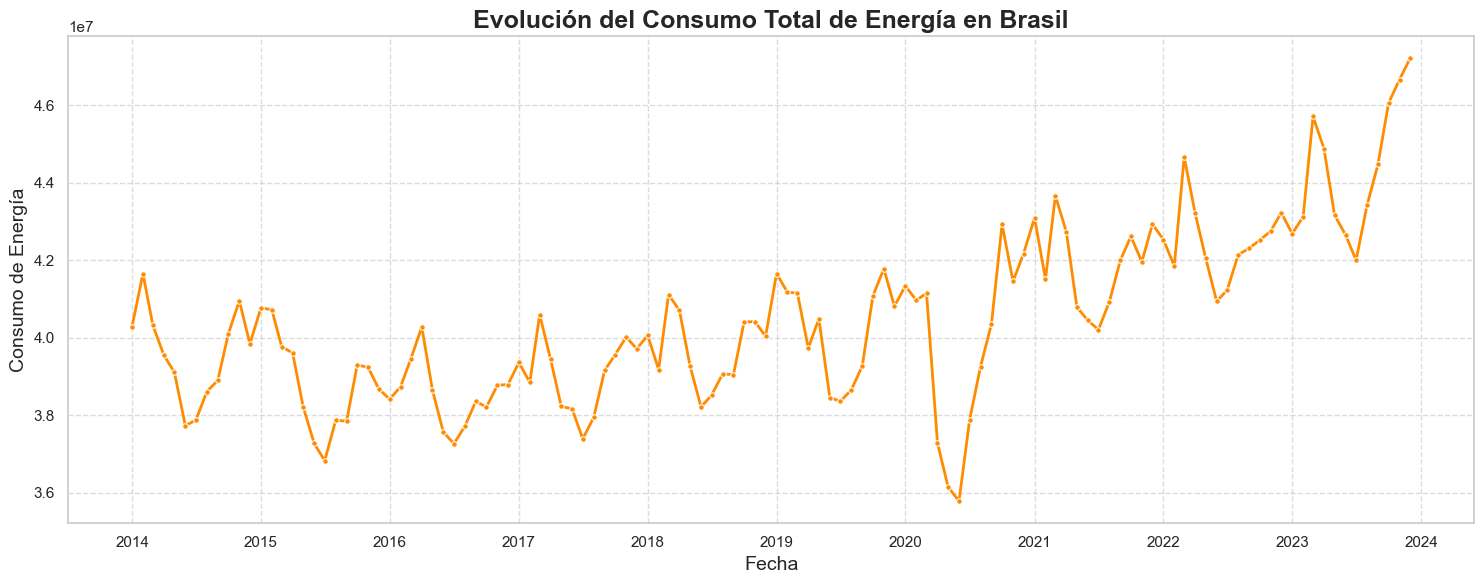

In [7]:
# 1. Agrupar los datos: Sumamos el consumo de todos los estados y sectores por cada fecha
consumo_nacional = df_brasil.groupby(df_brasil.index)['Consumo'].sum()

# 2. Configurar el tamaño del lienzo
plt.figure(figsize=(15, 6))

# 3. Crear el gráfico de línea de tiempo
sns.lineplot(x=consumo_nacional.index, y=consumo_nacional.values, color='darkorange', linewidth=2, marker='o', markersize=4)

# 4. Personalizar textos y estilo
plt.title('Evolución del Consumo Total de Energía en Brasil', fontsize=18, fontweight='bold')
plt.xlabel('Fecha', fontsize=14)
plt.ylabel('Consumo de Energía', fontsize=14)

# Añadimos una cuadrícula punteada para leer mejor los picos
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()

# Mostrar el gráfico
plt.show()

### Análisis del gráfico.
Se observa que el consumo en Brasil ha seguido una tendencia alcista durante el periodo analizado, lo que refleja un crecimiento constante en la demanda del país. Sin embargo, el momento más impactante ocurre en 2020, donde se ve una caída brusca y profunda causada por el freno de la pandemia. Luego de ese golpe, el país no solo se recuperó rápido, sino que para 2023 alcanzó niveles récord en el consumo. Además, los constantes 'sube y baja' que se repiten cada año nos muestran cómo el clima (como el calor del verano) marca el ritmo del consumo. A este patrón se lo conoce como comportamiento estacional.

### Análisis Temporal y Regional Detallado

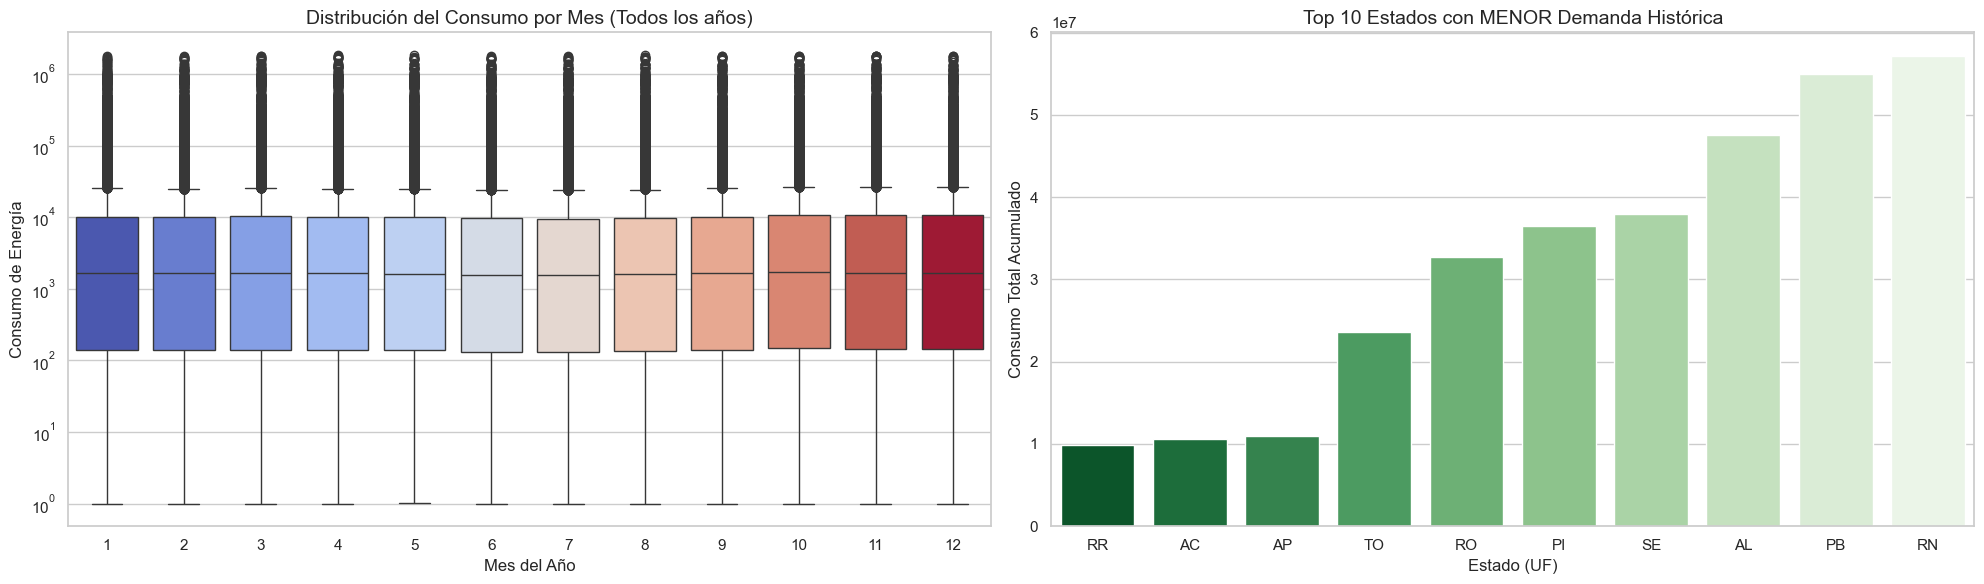

In [8]:
from matplotlib.pyplot import legend
# 1. Extraer el Mes y el Año del índice temporal para agrupar
df_brasil['Mes'] = df_brasil.index.month
df_brasil['Ano'] = df_brasil.index.year

# Configuramos una figura con dos subgráficos (1 fila, 2 columnas)
fig, axes = plt.subplots(1, 2, figsize=(20,6))

# --- GRÁFICO 1: Estacionalidad Mensual ---
# Usamos un boxplot para ver cómo se comporta cada mes a lo largo de todos los años
sns.boxplot(data=df_brasil, x='Mes', y='Consumo', ax=axes[0], palette='coolwarm', hue='Mes', legend=False)
axes[0].set_title('Distribución del Consumo por Mes (Todos los años)', fontsize=14)
axes[0].set_xlabel('Mes del Año', fontsize=12)
axes[0].set_ylabel('Consumo de Energía', fontsize=12)
axes[0].set_yscale('log')

# --- GRÁFICO 2: Demanda por Estado (UF - Unidade Federativa) ---
# Sumamos el consumo histórico por estado y tomamos los 10 con MENOR consumo (nuestros candidatos)
consumo_por_estado = df_brasil.groupby('UF')['Consumo'].sum().sort_values()
# Tomamos los 10 estados con menos consumo
estados_baja_demanda = consumo_por_estado.head(10)

sns.barplot(x=estados_baja_demanda.index, y=estados_baja_demanda.values, ax=axes[1], palette='Greens_r', hue=estados_baja_demanda.index, legend=False)
axes[1].set_title('Top 10 Estados con MENOR Demanda Histórica', fontsize=14)
axes[1].set_xlabel('Estado (UF)', fontsize=12)
axes[1].set_ylabel('Consumo Total Acumulado', fontsize=12)

plt.tight_layout()
plt.show()

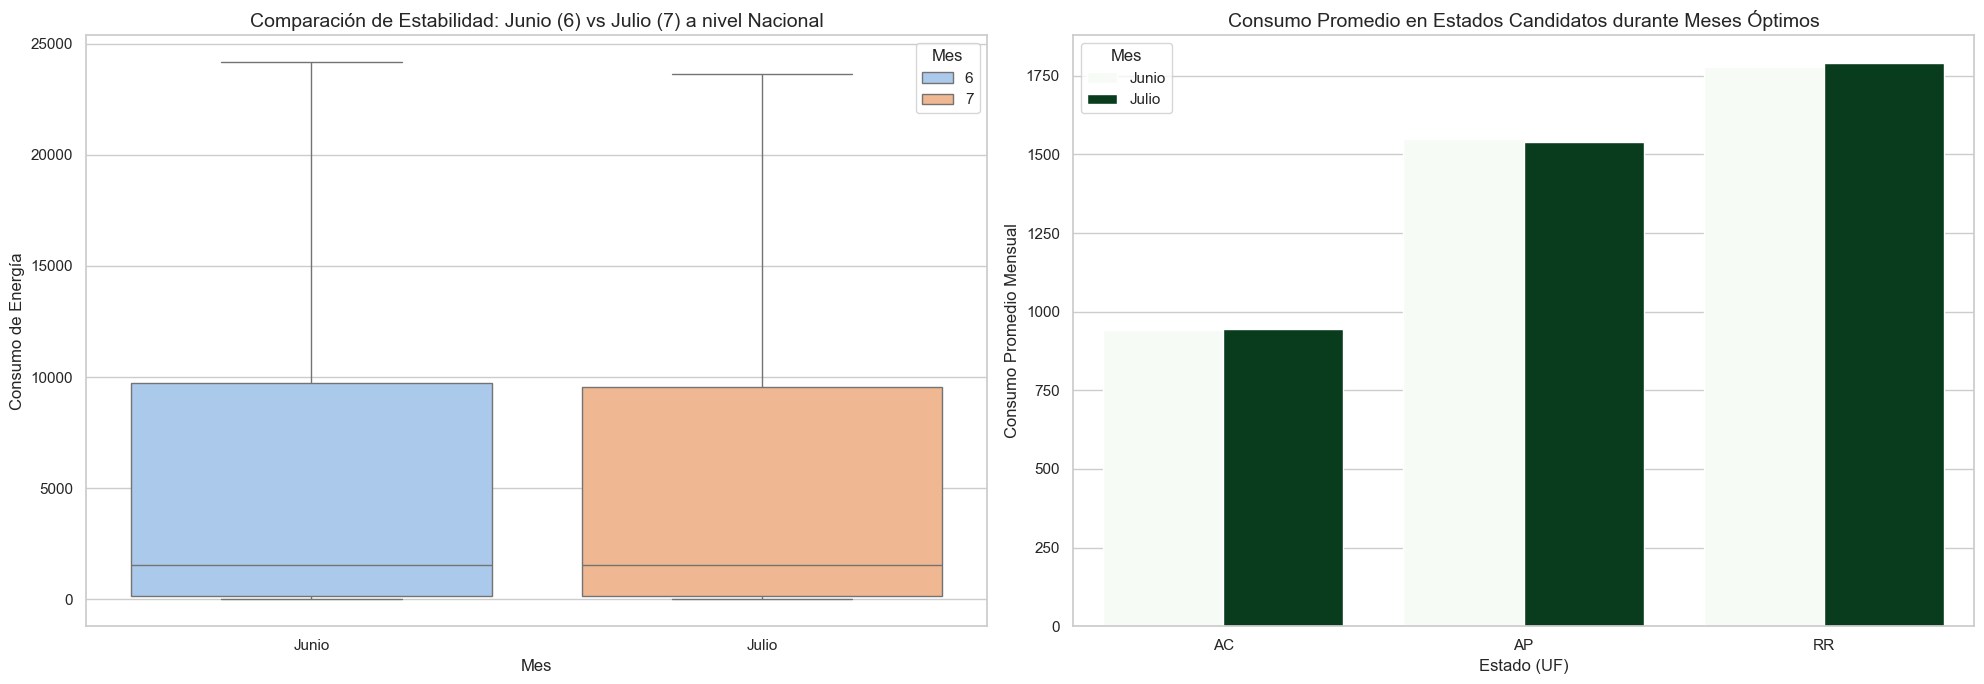

In [9]:
# 1. CREAR FILTROS DE PRECISION
# Filtramos meses óptimos
df_meses_optimos = df_brasil[df_brasil['Mes'].isin([6,7])].copy()

# Filtramos estados óptimos (dentro de todo el dataset para comparar)
estados_candidatos = ['RR', 'AC', 'AP']
df_estados_optimos = df_brasil[df_brasil['UF'].isin(estados_candidatos)].copy()

# Combinación final: Estados óptimos DURANTE meses óptimos
df_final_data_center = df_brasil[
    df_brasil['Mes'].isin([6,7]) &
    df_brasil['UF'].isin(estados_candidatos)
].copy()

# VISUALIZACIÓN DE PRECISIÓN 
fig, axes = plt.subplots(1, 2, figsize=(20,7))

# --- GRÁFICO A: Batalla de Meses Óptimos (Nacional) ---
# Comparamos la distribución nacional solo de Junio vs Julio sin outliers para ver estabilidad
sns.boxplot(data=df_meses_optimos, x='Mes', y='Consumo', hue='Mes',
            ax=axes[0], palette='pastel', showfliers=False)
axes[0].set_xticks([0,1])
axes[0].set_title('Comparación de Estabilidad: Junio (6) vs Julio (7) a nivel Nacional', fontsize=14)
axes[0].set_ylabel('Consumo de Energía', fontsize=12)
axes[0].set_xticklabels(['Junio', 'Julio'])

# --- GRÁFICO A: El Estado Ganador ---
# Comparamos el consumo promedio mensual de los 3 estados candidatos durante los meses de Junio y Julio
df_grouped_final = df_final_data_center.groupby(['UF', 'Mes'])['Consumo'].mean().reset_index()


sns.barplot(data=df_grouped_final, x='UF', y='Consumo', hue='Mes',
palette='Greens', ax=axes[1])

axes[1].set_title('Consumo Promedio en Estados Candidatos durante Meses Óptimos', fontsize=14)
axes[1].set_ylabel('Consumo Promedio Mensual', fontsize=12)
axes[1].set_xlabel('Estado (UF)', fontsize=12)

# Ajuste de leyenda para que diga los nombres de los meses
leg = axes[1].get_legend()
leg.set_title('Mes')
new_labels = ['Junio', 'Julio']
for t, l in zip(leg.get_texts(), new_labels): t.set_text(l)

plt.tight_layout()
plt.show()

### Conclusión Estratégica: Ubicación del Data Center

Tras una limpieza rigurosa de las anomalías en los datos (sensores inactivos o registros negativos), el panorama real de la demanda energética reveló un giro importante en nuestra búsqueda de "energía holgada":

* **La Ubicación Óptima:** **Acre (AC)** es el ganador definitivo. Presenta la demanda energética real más baja de los candidatos (promedio de ~1000 unidades). Roraima (RR), que parecía prometedor en los datos brutos, resultó ser un falso positivo arrastrado por ruido estadístico.
* **La Ventana Operativa:** **Julio** se confirma como el mes más estable a nivel nacional. Su varianza es menor (caja más compacta en el boxplot), lo que reduce drásticamente el riesgo de enfrentar picos de demanda imprevistos en la red eléctrica.

**Veredicto Final:** Para maximizar la eficiencia y operar en la red menos estresada de Brasil, el centro de datos debe instalarse físicamente en **Acre (AC)**, programando las ventanas de mantenimiento pesado o picos de procesamiento máximo durante el mes de **Julio**.

### Redifinición de Estrategia

Estados con infraestructura robusta: ['SP', 'MG', 'RJ', 'PR', 'RS', 'SC', 'BA', 'PA', 'GO', 'PE']


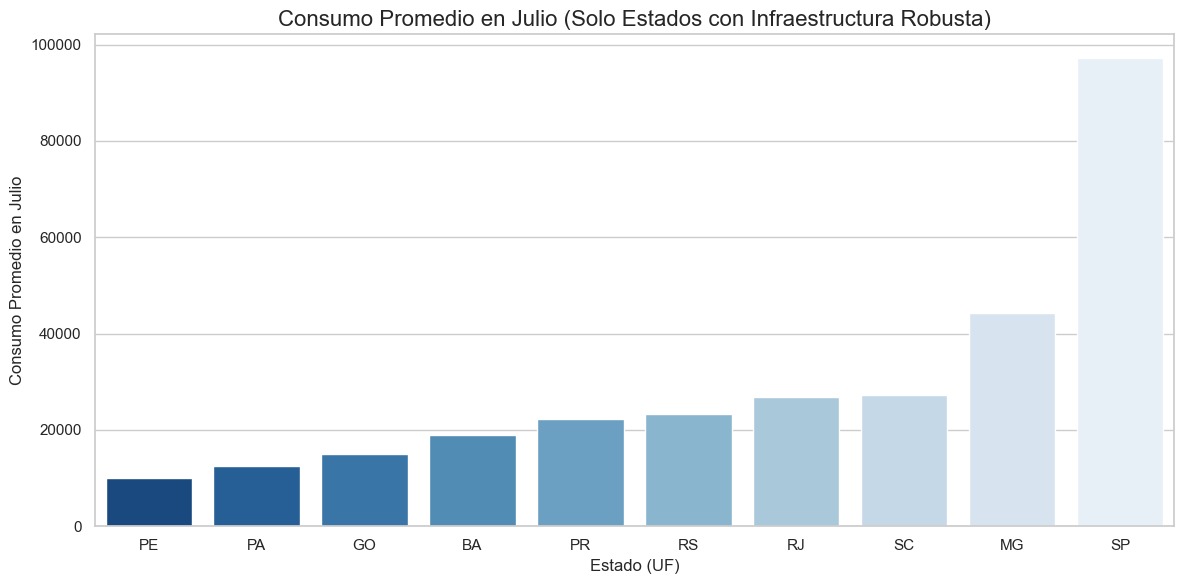

In [10]:
# --- NUEVA ESTRATEGIA: Filtrando por Infraestructura y Clima ---

# 1. Definir el "Piso de Infraestructura"
# Sumamos el consumo histórico por estado para ver quiénes son los "gigantes"
consumo_total_estado = df_brasil.groupby('UF')['Consumo'].sum().sort_values(ascending=False)

# Nos quedamos con los 10 estados con MAYOR infraestructura eléctrica del país
estados_infraestructura_top = consumo_total_estado.head(10).index.to_list()
print(f"Estados con infraestructura robusta: {estados_infraestructura_top}")

# 2. Filtrar nuestro dataset original para usar SOLO estos estados top
df_estados_fuertes = df_brasil[df_brasil['UF'].isin(estados_infraestructura_top)].copy()

# 3. Buscar el estado "fuerte" con el menor promedio durante el mes óptimo (Julio - 7)
df_julio_fuertes = df_estados_fuertes[df_estados_fuertes['Mes'] == 7]
consumo_julio_fuertes = df_julio_fuertes.groupby('UF')['Consumo'].mean().sort_values()

# 4. Visualizar al verdadero ganador
plt.figure(figsize=(12,6))
sns.barplot(x=consumo_julio_fuertes.index, y=consumo_julio_fuertes.values, palette='Blues_r', hue=consumo_julio_fuertes.index)
plt.title('Consumo Promedio en Julio (Solo Estados con Infraestructura Robusta)', fontsize=16)
plt.xlabel('Estado (UF)', fontsize=12)
plt.ylabel('Consumo Promedio en Julio', fontsize=12)

plt.tight_layout()
plt.show()


### Corrección Estratégica: Infraestructura vs. Consumo Absoluto

Nuestro análisis preliminar apuntaba a estados amazónicos (como Acre) debido a su bajo consumo absoluto. Sin embargo, aplicando conocimiento de dominio del sector tecnológico, identificamos que un consumo extremadamente bajo a nivel estatal es un indicador de **falta de infraestructura eléctrica**, no de energía excedente. Construir un Data Center de nivel industrial allí colapsaría la red local.

**El Pivote Analítico:**
Hemos ajustado nuestro modelo para buscar "ventanas de baja demanda" **exclusivamente dentro del Top 10 de estados con mayor infraestructura eléctrica del país**, garantizando que la red pueda soportar nuestras operaciones.

**Conclusión Final:**
Al cruzar el mes de mayor estabilidad nacional (Julio) con los estados de infraestructura robusta, nuestro ganador definitivo es **Pernambuco (PE)**. 
Esta ubicación nos garantiza:
1. Una red eléctrica madura y robusta (Top 10 nacional).
2. La menor saturación de red dentro de los "gigantes" durante la ventana operativa de invierno (Julio).
3. Viabilidad técnica real para operaciones de grado empresarial.